# Module 1: Basic Probability & Statistics

Welcome to the first hands-on notebook for Statistical Inference and Modelling!

This module revisits fundamental concepts of probability, random variables, and probability distributions. We will use Python to explore these concepts practically.

### Learning Objectives:
- Perform exploratory data analysis (EDA) with descriptive statistics.
- Understand and simulate basic probability concepts.
- Explore key random variables and their distributions (Binomial, Poisson, Normal).
- Differentiate between parametric and non-parametric approaches (Conceptual).

## Section 1: Setting up the Environment

We begin by importing the necessary Python libraries. These tools are essential for data manipulation, numerical computation, and visualization.

In [1]:
# Import necessary libraries
import numpy as np # For numerical operations
import pandas as pd # For data manipulation and analysis
import matplotlib.pyplot as plt # For plotting
import seaborn as sns # For statistical data visualization
from scipy import stats # For statistical functions

# Setting style for visualizations
sns.set_style("whitegrid")
np.random.seed(42) # ensures reproducibility

print("Libraries imported successfully!")

Libraries imported successfully!


## Section 2: Exploratory Data Analysis (EDA) and Descriptive Statistics

Descriptive statistics summarize the main features of a dataset. This is the first step in any data analysis.

Let's start with the fundamental concepts of **Population** and **Sample**.

- **Population:** The entire group that you want to draw conclusions about (e.g., all citizens of a country).
- **Sample:** A specific subset of the population from which you collect data (e.g., 1000 randomly selected citizens).

In [2]:
# Let's simulate a population.
# Imagine a population of 50,000 individuals and their annual incomes.
# Income data is often skewed, so we use a gamma distribution to model it.
population_incomes = np.random.gamma(shape=5, scale=10000, size=50000)

print(f"Population size: {len(population_incomes)}")
print(f"Population Mean Income (μ): ${np.mean(population_incomes):.2f}")

# Now, let's draw a random sample of 200 individuals from this population.
sample_incomes = np.random.choice(population_incomes, size=200, replace=False)

print(f"\nSample size: {len(sample_incomes)}")
print(f"Sample Mean Income (x̄): ${np.mean(sample_incomes):.2f}")
# Note how the sample mean is close to, but not exactly the same as, the population mean.

Population size: 50000
Population Mean Income (μ): $50087.50

Sample size: 200
Sample Mean Income (x̄): $49741.70


### 2.1 Measures of Central Tendency (Mean, Median, Mode)

These measures describe the 'center' of the data.

In [12]:
# Calculate the Mean (Average)
sample_mean = np.mean(sample_incomes)
print(f"Mean Income: ${sample_mean:.2f}")

# Calculate the Median (The middle value when data is sorted)
# Median is robust to outliers and is often better for skewed data.
sample_median = np.median(sample_incomes)
print(f"Median Income: ${sample_median:.2f}")

# Calculate the Mode (The most frequent value)
# Mode is typically used for categorical data. Let's look at a categorical example:
favorite_colors = np.random.choice(['Red', 'Blue', 'Green', 'Red', 'Blue', 'Blue', 'Yellow'], 50)
# Using np.unique to find the mode for categorical data
unique_colors, counts = np.unique(favorite_colors, return_counts=True)
mode_index = np.argmax(counts)
mode_color = unique_colors[mode_index]
print(f"\nMode of Favorite Colors: {mode_color}")

Mean Income: $49741.70
Median Income: $46978.97

Mode of Favorite Colors: Blue


### 2.2 Measures of Dispersion (Variance, Standard Deviation, Range)

These measures describe how 'spread out' the data is.

In [4]:
# Range (Difference between maximum and minimum)
sample_range = np.max(sample_incomes) - np.min(sample_incomes)
print(f"Range of Incomes: ${sample_range:.2f}")

# Variance (Average of squared differences from the Mean)
# We use ddof=1 (Degrees of Freedom = 1) for sample variance (Bessel's correction).
sample_variance = np.var(sample_incomes, ddof=1)
print(f"Variance of Incomes: {sample_variance:.2f}")

# Standard Deviation (Square root of the Variance)
# This tells us the typical distance of a data point from the mean.
sample_std = np.std(sample_incomes, ddof=1)
print(f"Standard Deviation of Incomes: ${sample_std:.2f}")

Range of Incomes: $102053.08
Variance of Incomes: 434341208.18
Standard Deviation of Incomes: $20840.85


### 2.3 Visualizing Data

Visualizations help us understand the distribution and characteristics of the data.

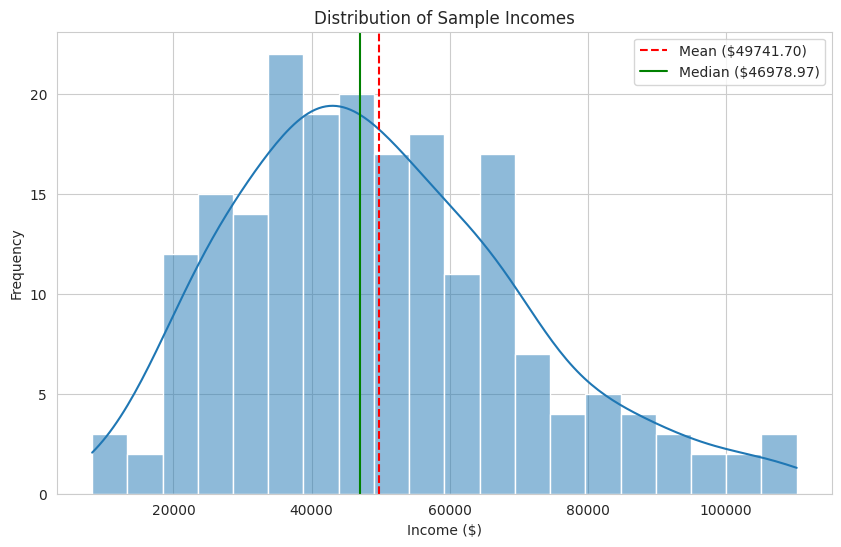

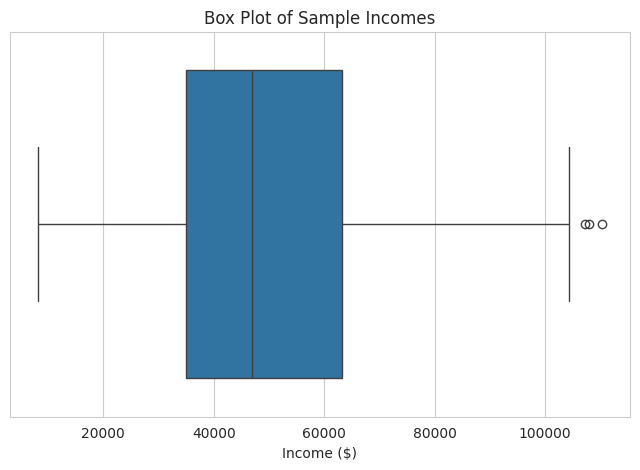

In [5]:
plt.figure(figsize=(10, 6))

# Histogram: Shows the frequency distribution of the incomes.
# The KDE (Kernel Density Estimate) provides a smooth curve of the distribution.
sns.histplot(sample_incomes, kde=True, bins=20)
plt.title('Distribution of Sample Incomes')
plt.xlabel('Income ($)')
plt.ylabel('Frequency')

# Adding Mean and Median lines to see the skewness
plt.axvline(sample_mean, color='r', linestyle='--', label=f'Mean (${sample_mean:.2f})')
plt.axvline(sample_median, color='g', linestyle='-', label=f'Median (${sample_median:.2f})')
plt.legend()
plt.show()
# Observation: Since Mean > Median, the distribution is right-skewed.

# Box Plot (Box-and-Whisker Plot): Shows the quartiles (IQR) and potential outliers.
plt.figure(figsize=(8, 5))
sns.boxplot(x=sample_incomes)
plt.title('Box Plot of Sample Incomes')
plt.xlabel('Income ($)')
plt.show()

## Section 3: Basic Probability Concepts

Probability is the measure of the likelihood that an event will occur.

- **Sample Space:** The set of all possible outcomes (e.g., {1, 2, 3, 4, 5, 6} for a die roll).
- **Event:** A subset of the sample space (e.g., rolling an even number {2, 4, 6}).

### 3.1 Simulating Experiments and the Law of Large Numbers

We can use Python to simulate random experiments. The Law of Large Numbers states that as the number of trials increases, the empirical probability approaches the theoretical probability.

In [6]:
# Simulating 10 coin flips (0=Tails, 1=Heads)
flips = np.random.randint(0, 2, size=10)
print(f"10 Flips: {flips}")
print(f"Empirical Probability of Heads (10 flips): {np.sum(flips)/10:.4f}")

# Simulating 10000 coin flips
many_flips = np.random.randint(0, 2, size=10000)
empirical_prob_heads = np.sum(many_flips) / 10000

print(f"Empirical Probability of Heads (10000 flips): {empirical_prob_heads:.4f}")
# This value is much closer to the theoretical probability (0.5).

10 Flips: [1 0 0 0 0 0 0 0 0 1]
Empirical Probability of Heads (10 flips): 0.2000
Empirical Probability of Heads (10000 flips): 0.5158


### 3.2 Conditional Probability

The probability of event A occurring given that event B has already occurred. $P(A|B) = P(A \cap B) / P(B)$.

Example: In a survey of 100 people, we look at the relationship between Smoking (S) and Lung Disease (L).

In [7]:
# Data represented in a contingency table
#                | Lung Disease (L) | No Lung Disease | Total
# -----------------------------------------------------------
# Smoker (S)     | 15               | 25              | 40
# Non-Smoker     | 5                | 55              | 60
# -----------------------------------------------------------
# Total          | 20               | 80              | 100

Total = 100

# P(S) = Probability of being a smoker
P_S = 40 / Total

# P(L ∩ S) = Probability of having lung disease AND being a smoker
P_L_and_S = 15 / Total

# Question: What is the probability of having Lung Disease GIVEN that the person is a Smoker? P(L|S)
# P(L|S) = P(L ∩ S) / P(S)
P_L_given_S = P_L_and_S / P_S

print(f"P(S): {P_S:.3f}")
print(f"P(L|S): {P_L_given_S:.3f}")

# Interpretation: While the overall probability of smoking is 40%, if we know someone is a smoker, the probability they have lung disease is 37.5%.

P(S): 0.400
P(L|S): 0.375


## Section 4: Random Variables and Distributions

A **Random Variable** is a variable whose value is a numerical outcome of a random phenomenon.

- **Discrete:** Takes countable distinct values (e.g., number of defective items).
- **Continuous:** Takes an infinite number of possible values within a range (e.g., temperature).

### 4.1 Discrete Distribution: Binomial Distribution

Models the number of successes in a fixed number of independent Bernoulli trials.

Parameters: `n` (number of trials), `p` (probability of success).

P(X=6): 0.2051
P(X<=6): 0.8281


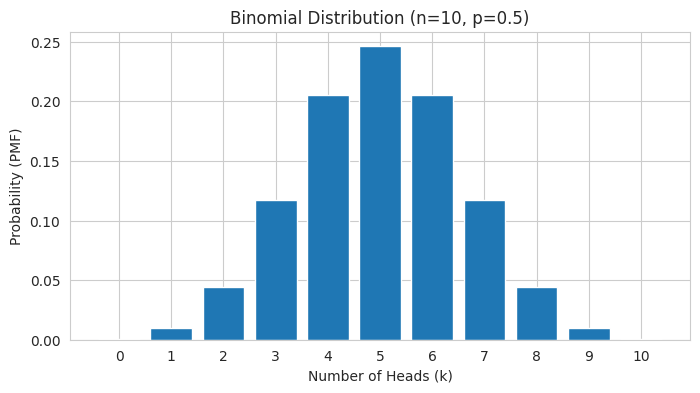

In [8]:
# Example: Flipping a fair coin 10 times (n=10, p=0.5).
n = 10
p = 0.5

# What is the probability of getting exactly 6 heads (k=6)?
# We use the Probability Mass Function (PMF)
prob_6_heads = stats.binom.pmf(k=6, n=n, p=p)
print(f"P(X=6): {prob_6_heads:.4f}")

# What is the probability of getting 6 or fewer heads (k<=6)?
# We use the Cumulative Distribution Function (CDF)
prob_6_or_fewer = stats.binom.cdf(k=6, n=n, p=p)
print(f"P(X<=6): {prob_6_or_fewer:.4f}")

# Visualizing the Binomial Distribution
k_values = np.arange(0, n + 1)
pmf_values = stats.binom.pmf(k_values, n=n, p=p)

plt.figure(figsize=(8, 4))
plt.bar(k_values, pmf_values)
plt.title('Binomial Distribution (n=10, p=0.5)')
plt.xlabel('Number of Heads (k)')
plt.ylabel('Probability (PMF)')
plt.xticks(k_values)
plt.show()

### 4.2 Discrete Distribution: Poisson Distribution

Models the number of events occurring in a fixed interval of time or space, given the average rate.

Parameter: `lambda` (λ) (average rate).

P(X=3): 0.1404


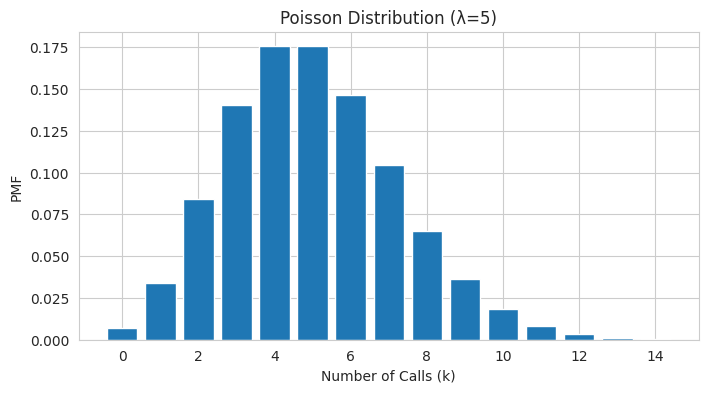

In [9]:
# Example: A call center receives an average of 5 calls per hour (lambda=5).
lam = 5

# What is the probability of exactly 3 calls in the next hour? (PMF)
prob_3_calls = stats.poisson.pmf(k=3, mu=lam)
print(f"P(X=3): {prob_3_calls:.4f}")

# Visualizing the Poisson Distribution
k_values = np.arange(0, 15)
pmf_values = stats.poisson.pmf(k_values, mu=lam)

plt.figure(figsize=(8, 4))
plt.bar(k_values, pmf_values)
plt.title('Poisson Distribution (λ=5)')
plt.xlabel('Number of Calls (k)')
plt.ylabel('PMF')
plt.show()

### 4.3 Continuous Distribution: Normal Distribution (Gaussian)

The 'bell curve'. It is crucial in statistics due to the Central Limit Theorem.

Parameters: `mu` (μ) (mean), `sigma` (σ) (standard deviation).

P(X < 60): 0.1587
P(X > 90): 0.0228


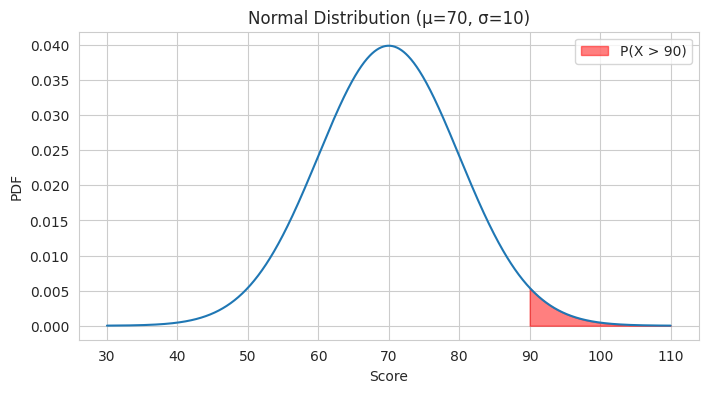

In [10]:
# Example: Exam scores are normally distributed with mean 70 and std dev 10.
mu = 70
sigma = 10

# What is the probability that a student scores less than 60?
# P(X < 60) = CDF(60)
prob_less_60 = stats.norm.cdf(x=60, loc=mu, scale=sigma)
print(f"P(X < 60): {prob_less_60:.4f}")

# What is the probability that a student scores more than 90?
# P(X > 90) = 1 - P(X <= 90) = 1 - CDF(90)
prob_more_90 = 1 - stats.norm.cdf(x=90, loc=mu, scale=sigma)
print(f"P(X > 90): {prob_more_90:.4f}")

# Visualizing the Normal Distribution (Probability Density Function - PDF)
x_values = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
pdf_values = stats.norm.pdf(x_values, loc=mu, scale=sigma)

plt.figure(figsize=(8, 4))
plt.plot(x_values, pdf_values)
plt.title('Normal Distribution (μ=70, σ=10)')
plt.xlabel('Score')
plt.ylabel('PDF')
# Shading the area for P(X > 90)
x_fill = np.linspace(90, mu + 4*sigma, 100)
y_fill = stats.norm.pdf(x_fill, loc=mu, scale=sigma)
plt.fill_between(x_fill, y_fill, color='red', alpha=0.5, label='P(X > 90)')
plt.legend()
plt.show()

## Section 5: Parametric vs. Non-Parametric Approaches

When performing statistical analysis, we categorize methods based on the assumptions they make about the population distribution.

### Parametric Methods
- **Assumption:** Assume the data follows a specific distribution (e.g., Normal distribution).
- **Examples:** t-tests, ANOVA, Pearson correlation.
- **Advantage:** More statistical power (better at detecting effects) when assumptions are met.

### Non-Parametric Methods
- **Assumption:** Do not rely on specific distributional assumptions (distribution-free).
- **Examples:** Mann-Whitney U test, Kruskal-Wallis test, Spearman correlation.
- **Advantage:** More robust when assumptions are violated (e.g., skewed data, small samples).

In [11]:
# Example: Comparing the center of skewed data
skewed_data = np.random.exponential(scale=10, size=20) # Small, skewed sample

# Parametric approach often focuses on the Mean
print(f"Mean (Parametric focus): {np.mean(skewed_data):.2f}")

# Non-Parametric approach often focuses on the Median (which is more robust to skew)
print(f"Median (Non-Parametric focus): {np.median(skewed_data):.2f}")

# If we were testing if the center of this population is 10:
# Parametric (t-test - might be unreliable here due to small size and skew)
t_stat, p_val_para = stats.ttest_1samp(skewed_data, 10)
print(f"\nT-test p-value (Parametric): {p_val_para:.4f}")

# Non-Parametric (Wilcoxon signed-rank test - tests the median)
w_stat, p_val_nonpara = stats.wilcoxon(skewed_data - 10)
print(f"Wilcoxon test p-value (Non-Parametric): {p_val_nonpara:.4f}")

Mean (Parametric focus): 9.23
Median (Non-Parametric focus): 8.15

T-test p-value (Parametric): 0.6506
Wilcoxon test p-value (Non-Parametric): 0.3683
